In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

from pathlib import Path
BASE_DIR = Path.cwd().parent
print(f"Base directory: {BASE_DIR}")

def count_chunks(videoBasePath):
    """Counts the 16 frames lenght chunks available in a dataset organized in violent and non-violent,
    cam1 and cam2 folders, placed at videoBasePath.

    Parameters
    ----------
    videoBasePath : str
                    Base path of the dataset

    Returns
    -------
    cnt : int
          number of 16 frames lenght chunks in the dataset
    """

    folders = ['non-violence', 'low-level violence', 'high-level violence']
    cams = ['cam1', 'cam2']
    cnt = 0

    for folder in folders:
        for camName in cams:
            path = os.path.join(videoBasePath, folder, camName)

            videofiles = os.listdir(path)
            for videofile in videofiles:
                filePath = os.path.join(path, videofile)
                video = cv2.VideoCapture(filePath)
                numframes = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
                fps = int(video.get(cv2.CAP_PROP_FPS))
                chunks = numframes//16
                cnt += chunks


    return cnt

Base directory: d:\Myworkplace\Python\violence-movies


### 1. Create Model

In [ ]:
# downloads C3D weights from https://github.com/aslucki/C3D_Sport1M_keras
!mkdir -p ../c3d_weight
!gdown --id 1rlZ-xTkTMjgWKiQFUedRnHlDgQwx6yTm -O ../c3d_weight/3dcnn_weights.h5

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1rlZ-xTkTMjgWKiQFUedRnHlDgQwx6yTm
From (redirected): https://drive.google.com/uc?id=1rlZ-xTkTMjgWKiQFUedRnHlDgQwx6yTm&confirm=t&uuid=65700b2e-04f0-46c5-99ea-7270f21138cf
To: /content/pretrain_weights/3dcnn_weights.h5
100% 320M/320M [00:04<00:00, 67.6MB/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow import keras
from tensorflow.keras.layers import (Input, Conv3D, MaxPooling3D, ZeroPadding3D, Flatten, Dense, LSTM, ConvLSTM2D,
                                     TimeDistributed, Dropout, GlobalAveragePooling2D, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

def create_C3D_model(summary = False):
    """Creates model object with the sequential API: https://keras.io/models/sequential/

    Parameters
    ----------
    summary : bool
              if True, prints the model summary (default False)

    Returns
    -------
    model : Sequential
            The instantiated model
    """

    model = Sequential()
    input_shape = (16, 112, 112, 3)

    model.add(Conv3D(64, (3, 3, 3), activation='relu',
                     padding='same', name='conv1',
                     input_shape=input_shape))
    model.add(MaxPooling3D(pool_size=(1, 2, 2), strides=(1, 2, 2),
                           padding='valid', name='pool1'))
    # 2nd layer group
    model.add(Conv3D(128, (3, 3, 3), activation='relu',
                     padding='same', name='conv2'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool2'))
    # 3rd layer group
    model.add(Conv3D(256, (3, 3, 3), activation='relu',
                     padding='same', name='conv3a'))
    model.add(Conv3D(256, (3, 3, 3), activation='relu',
                     padding='same', name='conv3b'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool3'))
    # 4th layer group
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv4a'))
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv4b'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool4'))
    # 5th layer group
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv5a'))
    model.add(Conv3D(512, (3, 3, 3), activation='relu',
                     padding='same', name='conv5b'))
    model.add(ZeroPadding3D(padding=((0, 0), (0, 1), (0, 1)), name='zeropad5'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool5'))
    model.add(Flatten())
    # FC layers group
    model.add(Dense(4096, activation='relu', name='fc6'))
    model.add(Dropout(.5))
    model.add(Dense(4096, activation='relu', name='fc7'))
    model.add(Dropout(.5))
    model.add(Dense(487, activation='softmax', name='fc8'))

    if summary:
      print(model.summary())

    return model

def create_C3D_refined_model(summary = False):
    """

    Parameters
    ----------
    summary : bool
              if True, prints the model summary (default False)

    Returns
    -------
    model : Sequential
            The instantiated model
    """

    model = Sequential()
    input_shape = (16, 112, 112, 3)

    model.add(Conv3D(64, (3, 3, 3), activation='relu',
                     padding='same', name='conv1',
                     input_shape=input_shape))
    model.add(MaxPooling3D(pool_size=(1, 2, 2), strides=(1, 2, 2),
                           padding='valid', name='pool1'))
    # 2nd layer group
    model.add(Conv3D(128, (3, 3, 3), activation='relu',
                     padding='same', name='conv2'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool2'))
    # 3rd layer group
    model.add(Conv3D(256, (3, 3, 3), activation='relu',
                     padding='same', name='conv3a'))
    model.add(Conv3D(256, (3, 3, 3), activation='relu',
                     padding='same', name='conv3b'))
    model.add(MaxPooling3D(pool_size=(2, 2, 2), strides=(2, 2, 2),
                           padding='valid', name='pool3'))

    if summary:
      print(model.summary())

    return model

def getFeatureExtractor(weightsPath, layer, verbose = False):
    """Gets the C3D feature extractor

    Parameters
    ----------
    weightsPath : str
                  Pathname of the weights file for the C3D model.
    layer : str
            Name of the output layer for the feature extractor
    verbose : bool
              if True print debug logs (default True)

    Returns
    -------

    Model : Model class
            Feature extractor

    """

    keras.backend.clear_session()

    base = create_C3D_model(summary=verbose)  # Sequential built with tf.keras layers

    inp = keras.Input(shape=(16, 112, 112, 3), name="c3d_input")
    x = inp
    pool3_tensor = None

    # Build ONE functional graph using the SAME layer objects
    for l in base.layers:
        x = l(x)
        if l.name == layer:
            pool3_tensor = x

    if pool3_tensor is None:
        raise ValueError(f"Layer '{layer}' not found in model. Available: {[l.name for l in base.layers]}")

    # Load weights AFTER the graph exists
    base.load_weights(weightsPath, by_name=True, skip_mismatch=True)

    feat = keras.Model(inputs=inp, outputs=pool3_tensor, name=f"c3d_{layer}")
    return feat

def getC3DCNNModel(verbose=True, freeze_backbone=True, lr=1e-4):
    """Creates the C3D + fully connected layers end-to-end model object with the
    sequential API: https://keras.io/models/sequential/

    Parameters
    ----------
    verbose : bool
              if True prints the model summary (default True)

    Returns
    -------
    model : Sequential
            The instantiated model
    """
    pretrainedModel = getFeatureExtractor(BASE_DIR / "c3d_weight"/ "3dcnn_weights.h5", 'fc6', False)
    for layer in pretrainedModel.layers:
        layer.trainable = not freeze_backbone

    dropout1 = Dropout(.5)(pretrainedModel.output)
    fc7Alt = Dense(512, activation='relu', name='fc7-alt')(dropout1)
    dropout2 = Dropout(.5)(fc7Alt)
    output = Dense(3, activation='softmax')(dropout2)
    model = Model(inputs=pretrainedModel.inputs, outputs=output)
    if verbose:
        model.summary()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999, epsilon=1e-08),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    del pretrainedModel

    return model

def getLSTMModel(verbose=True, freeze_backbone=None, lr=1e-4):
    """Creates the ConvLSTM + fully connected layers end-to-end model object
    with the sequential API: https://keras.io/models/sequential/

    Parameters
    ----------
    verbose : bool
              if True prints the model summary (default True)

    Returns
    -------
    model : Sequential
            The instantiated model
    """
    model = Sequential()
    model.add(ConvLSTM2D(filters=64, kernel_size=(3,3), input_shape=(16,112,112,3)))
    model.add(Dropout(0.5))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    if verbose:
        model.summary()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999, epsilon=1e-08),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

def get3DCNNLSTMModel(verbose=True, freeze_backbone=True, lr=1e-4):
    """Creates the 3DCNN + LSTM

    Parameters
    ----------
    verbose : bool
              if True prints the model summary (default True)

    Returns
    -------
    model : Sequential
            The instantiated model
    """
    pretrainedModel = getFeatureExtractor(BASE_DIR / "c3d_weight"/ "3dcnn_weights.h5", 'pool3', False)
    for layer in pretrainedModel.layers:
        layer.trainable = not freeze_backbone
        # layer.trainable = True

    # =========================
    # TimeDistributed(Flatten()) + LSTM
    # =========================
    # # (batch, 10, conv_filters)
    # x = TimeDistributed(Flatten())(pretrainedModel.output)
    # # (batch, lstm_units)
    # x = LSTM(64)(x)
    # =========================

    # or
    # =========================
    # ConvLSTM2D + BatchNormalization + GlobalAveragePooling2D
    # =========================
    # 2. Add ConvLSTM2D
    # We replace Flatten() and LSTM() with ConvLSTM2D
    # This keeps the (14, 14) spatial structure intact while processing the 4 time steps
    x = ConvLSTM2D(filters=64, kernel_size=(3, 3),
                   padding='same', return_sequences=False,
                   name='conv_lstm_layer')(pretrainedModel.output)

    # It's highly recommended to add BatchNormalization after ConvLSTM
    x = BatchNormalization()(x)

    # 3. Spatial Reduction
    # ConvLSTM2D (return_sequences=False) outputs (batch, 14, 14, 64)
    # Use GlobalAveragePooling2D to turn this into a vector of 64 features
    x = GlobalAveragePooling2D()(x)
    # =========================


    x = Dropout(.5)(x)
    # (batch, 256)
    x = Dense(256, activation='relu')(x)

    outputs = Dense(3, activation='softmax')(x)

    model = Model(pretrainedModel.inputs, outputs)
    if verbose:
        model.summary()

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999, epsilon=1e-08),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    del pretrainedModel

    return model

### 2. Training

In [7]:
from cv2.gapi import video
# definitions of two end-to-end models + definitions of experiments
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pylab as plt
from tensorflow.keras.callbacks import Callback
from collections import Counter

class VideoValAccuracyCallback(Callback):
    def __init__(self, X_val, y_val, video_val, n_classes):
        super().__init__()
        self.X_val = X_val
        self.y_val = np.asarray(y_val).astype(int)
        self.video_val = np.asarray(video_val)
        self.n_classes = n_classes

        self.chunk_val_accs = []
        self.video_val_accs = []

    def _video_ensemble_mean_prob(self, y_true_chunks, probas_chunks, video_ids, n_classes):
        unique_videos = np.unique(video_ids)

        video_true_list = []
        video_pred_list = []

        for vid in unique_videos:
            idx = (video_ids == vid)

            true_counts = np.bincount(y_true_chunks[idx], minlength=n_classes)
            video_true = np.argmax(true_counts)

            video_prob = np.mean(probas_chunks[idx], axis=0)
            video_pred = np.argmax(video_prob)

            video_true_list.append(video_true)
            video_pred_list.append(video_pred)

        video_true_arr = np.array(video_true_list)
        video_pred_arr = np.array(video_pred_list)

        video_acc = np.mean(video_true_arr == video_pred_arr)
        return video_acc

    def on_epoch_end(self, epoch, logs=None):
        probas = self.model.predict(self.X_val, batch_size=8, verbose=0)
        y_pred = np.argmax(probas, axis=1)

        chunk_acc = accuracy_score(self.y_val, y_pred)
        video_acc = self._video_ensemble_mean_prob(
            y_true_chunks=self.y_val,
            probas_chunks=probas,
            video_ids=self.video_val,
            n_classes=self.n_classes
        )

        self.chunk_val_accs.append(chunk_acc)
        self.video_val_accs.append(video_acc)

        print(f" — val_chunk_acc_manual: {chunk_acc:.4f} — val_video_acc: {video_acc:.4f}")

# Using ensemble method to test on video level
def runEndToEndExperiment(getModel, batchSize, datasetBasePath, mmapDatasetBasePath,
                          samplesMMapName, lablesMMapName, endToEndModelName, rState, class_names=None):
    """"Runs the tests with end to end models.

    Notes for multiclass (is_binary=False):
      - Expects labels y in {0,1,2} (int)
      - Expects model.predict(X) to return probabilities with shape (N, 3)
      - Uses argmax for predictions
      - Reports macro-avg precision/recall/F1 + accuracy + confusion matrices
      - (Optional) computes macro ROC-AUC (OvR) numerically (no ROC plot)

    Parameters
    ----------
    getModel : Callable[[bool], keras.Model]
               Function that instantiates the model to be tested.
               Called as getModel(i==1). Ensure it builds binary or 3-class model
               consistently with `is_binary`.
    batchSize : int
    datasetBasePath : str
    mmapDatasetBasePath : str
    samplesMMapName : str
    lablesMMapName : str
    endToEndModelName : str
    rState : int or None
    is_binary : bool
    class_names : list[str] or None
                  For multiclass, supply something like ["class0","class1","class2"].
    """


    # =========================
    # [UPDATED] VIDEO ENSEMBLE WITH CONFUSION SUPPORT
    # =========================
    def _video_ensemble_mean_prob(y_true_chunks, probas_chunks, video_ids, n_classes):
        """
        Aggregates chunk probabilities to video-level using mean probability.

        Returns:
            video_acc,
            video_true_labels,
            video_pred_labels
        """
        y_true_chunks = np.asarray(y_true_chunks).astype(int)
        probas_chunks = np.asarray(probas_chunks)
        video_ids = np.asarray(video_ids)

        unique_videos = np.unique(video_ids)

        video_true_list = []
        video_pred_list = []

        for vid in unique_videos:
            idx = (video_ids == vid)

            # True video label (majority safety)
            true_counts = np.bincount(y_true_chunks[idx], minlength=n_classes)
            video_true = np.argmax(true_counts)

            # Mean probability aggregation
            video_prob = np.mean(probas_chunks[idx], axis=0)
            video_pred = np.argmax(video_prob)

            video_true_list.append(video_true)
            video_pred_list.append(video_pred)

        video_true_arr = np.array(video_true_list)
        video_pred_arr = np.array(video_pred_list)

        video_acc = np.mean(video_true_arr == video_pred_arr)

        return video_acc, video_true_arr, video_pred_arr
    # =========================

    chunk_number = count_chunks(datasetBasePath)

    X = np.memmap(os.path.join(mmapDatasetBasePath, samplesMMapName),
                  mode='r', dtype=np.float32,
                  shape=(chunk_number, 16, 112, 112, 3))
    y = np.memmap(os.path.join(mmapDatasetBasePath, lablesMMapName),
                  mode='r', dtype=np.int8,
                  shape=(chunk_number,))
    videoname = np.memmap(os.path.join(mmapDatasetBasePath, 'videos.mmap'),
                          mode='r', dtype=np.int32,
                          shape=(chunk_number,))

    nsplits = 10
    # cv = StratifiedShuffleSplit(n_splits=nsplits, train_size=0.8, random_state=rState)
    cv = StratifiedGroupKFold(
        n_splits=nsplits,
        shuffle=True,
        random_state=rState
    )

    scores = []
    all_chunk_val_curves = []
    all_video_val_curves = []

    # ----- metrics containers -----
    # multiclass: macro metrics
    macro_precisions = np.zeros(shape=(nsplits))
    macro_recalls = np.zeros(shape=(nsplits))
    macro_f1s = np.zeros(shape=(nsplits))
    macro_aucs = np.zeros(shape=(nsplits))  # numeric macro AUC (OvR)
    train_accs = np.zeros(shape=(nsplits))
    if class_names is None:
        class_names = ["0", "1", "2"]

    # =========================
    # [ADDED] ENSEMBLE METRIC CONTAINERS (for both binary and 3-class)
    # =========================
    video_accs = np.zeros(shape=(nsplits))
    # =========================

    i = 1

    # for train, test in cv.split(X, y):
    for train, test in cv.split(X, y, groups=videoname):


        # Build train/test memmaps for this split
        X_train = np.memmap(os.path.join(mmapDatasetBasePath, 'samples_train.mmap'),
                            mode='w+', dtype=np.float32, shape=X[train].shape)
        X_train[:] = X[train][:]

        X_test = np.memmap(os.path.join(mmapDatasetBasePath, 'samples_test.mmap'),
                           mode='w+', dtype=np.float32, shape=X[test].shape)
        X_test[:] = X[test][:]


        # perm = np.random.RandomState(rState).permutation(len(train))
        # X_train = X_train[perm]
        y_train_full = np.asarray(y)[train]
        train_videos = np.asarray(videoname)[train]
        gss = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=rState)
        tr_idx, val_idx = next(gss.split(np.zeros(len(train)), y_train_full, groups=train_videos))

        X_tr = X_train[tr_idx]
        y_tr = y_train_full[tr_idx]

        X_val = X_train[val_idx]
        y_val = y_train_full[val_idx]
        video_val = train_videos[val_idx]

        print(f"\n[Fold {i}] Dataset sizes and distribution:")
        print(f"Train: {len(X_tr)}, dist: {Counter(y_tr)}")
        print(f"Val:   {len(X_val)}, dist: {Counter(y_val)}")
        print(f"Test:  {len(X_test)}, dist: {Counter(y[test])}")

        # Free main X mapping to reduce memory pressure; remap later
        del X

        # Build model
        # =========================
        # Stage 1: train top layers only
        # =========================
        model = getModel(i==1, freeze_backbone=True, lr=1e-5)

        es = EarlyStopping(monitor='val_loss', mode='min', patience=10,
                           verbose=1, restore_best_weights=True)

        video_val_cb = VideoValAccuracyCallback(
            X_val=X_val,
            y_val=y_val,
            video_val=video_val,
            n_classes=len(class_names)
        )

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=batchSize,
            verbose=1,
            callbacks=[es, video_val_cb]
        )


        all_chunk_val_curves.append(video_val_cb.chunk_val_accs)
        all_video_val_curves.append(video_val_cb.video_val_accs)

        # release train memmap
        del X_train

        print("Computing scores...")
        evaluation = model.evaluate(X_test, y[test], verbose=1)
        scores.append(evaluation)

        print("Computing probs...")
        probas = model.predict(X_test, batch_size=batchSize, verbose=1)

        # release test memmap ASAP after we have predictions (optional)
        del X_test

        # 3 classes classification code here
        probas_2d = np.asarray(probas)  # expected (N,3)
        y_pred = np.argmax(probas_2d, axis=1)

        best_epoch = np.argmax(history.history['val_accuracy'])
        train_acc_best = history.history['accuracy'][best_epoch]

        train_accs[i - 1] = train_acc_best

        print(f"[Fold {i}] Train accuracy (best epoch): {train_acc_best:.4f}")

        # =========================
        # [CHANGED] VIDEO-LEVEL ENSEMBLE (3-CLASS)
        # =========================

        video_acc, video_true_arr, video_pred_arr = _video_ensemble_mean_prob(
            y_true_chunks=np.asarray(y)[test],
            probas_chunks=probas_2d,
            video_ids=np.asarray(videoname)[test],
            n_classes=len(class_names)
        )
        video_accs[i - 1] = video_acc

        print(f"[Video MeanProb] split {i} | video-acc={video_acc:.4f}")

        print("Video-level Confusion Matrix")
        print(confusion_matrix(video_true_arr, video_pred_arr))

        print("Video-level Classification Report")
        print(classification_report(
            video_true_arr,
            video_pred_arr,
            target_names=class_names
        ))
        # =========================

        report = classification_report(
            y[test], y_pred,
            target_names=class_names,
            output_dict=True
        )

        macro_precisions[i - 1] = report['macro avg']['precision']
        macro_recalls[i - 1] = report['macro avg']['recall']
        macro_f1s[i - 1] = report['macro avg']['f1-score']

        # numeric macro ROC-AUC (OvR) if possible
        print("Test class distribution:", np.bincount(y[test], minlength=len(class_names)))
        try:
            y_true_bin = label_binarize(y[test], classes=list(range(len(class_names))))
            macro_aucs[i - 1] = roc_auc_score(
                y_true_bin, probas_2d,
                average="macro",
                multi_class="ovr"
            )
        except Exception:
            macro_aucs[i - 1] = np.nan

        print('confusion matrix split ' + str(i))
        print(confusion_matrix(y[test], y_pred))
        print(classification_report(y[test], y_pred, target_names=class_names))
        print('Loss: ' + str(evaluation[0]))
        print('Accuracy: ' + str(evaluation[1]))
        print('Macro Precision: ' + str(macro_precisions[i - 1]))
        print('Macro Recall: ' + str(macro_recalls[i - 1]))
        print('Macro F1: ' + str(macro_f1s[i - 1]))
        print('Macro ROC-AUC (OvR): ' + str(macro_aucs[i - 1]))
        print('\n')

        del report

        i += 1

        # Remap X for next split
        X = np.memmap(os.path.join(mmapDatasetBasePath, samplesMMapName),
                      mode='r', dtype=np.float32,
                      shape=(chunk_number, 16, 112, 112, 3))

        del model
        del probas
        tf.keras.backend.clear_session()

    # ------------------------------------------------------------
    #           SUMMARY / PLOTS
    # ------------------------------------------------------------

    # =========================
    # [ADDED] ENSEMBLE SUMMARY (BOTH BINARY + 3-CLASS)
    # =========================
    print('Video accuracy per split')
    print(video_accs)
    print("Avg video accuracy: {0} +/- {1}".format(np.mean(video_accs), np.std(video_accs)))
    # =========================

    # scores summary
    np_scores = np.array(scores, dtype=float)
    losses = np_scores[:, 0:1]
    accuracies = np_scores[:, 1:2]

    print('Train accuracy per split')
    print(train_accs)
    print('Losses')
    print(losses)
    print('Accuracies')
    print(accuracies)

    print('Macro Precisions')
    print(macro_precisions)
    print('Macro Recalls')
    print(macro_recalls)
    print('Macro F1-scores')
    print(macro_f1s)
    print('Macro ROC-AUC (OvR)')
    print(macro_aucs)

    print("Avg train accuracy: {0} +/- {1}".format(np.mean(train_accs), np.std(train_accs)))
    print("Avg loss: {0} +/- {1}".format(np.mean(losses), np.std(losses)))
    print("Avg accuracy: {0} +/- {1}".format(np.mean(accuracies), np.std(accuracies)))
    print("Avg macro precision: {0} +/- {1}".format(np.mean(macro_precisions), np.std(macro_precisions)))
    print("Avg macro recall: {0} +/- {1}".format(np.mean(macro_recalls), np.std(macro_recalls)))
    print("Avg macro f1: {0} +/- {1}".format(np.mean(macro_f1s), np.std(macro_f1s)))
    # macro_aucs may contain nan if computation failed
    print("Avg macro auc: {0} +/- {1}".format(np.nanmean(macro_aucs), np.nanstd(macro_aucs)))

    del macro_precisions, macro_recalls, macro_f1s, macro_aucs

    # [ADDED] cleanup ensemble arrays
    del video_accs

    del X, y, accuracies, losses, np_scores
    return all_chunk_val_curves, all_video_val_curves

#### 3DCNNLSTM Model

In [ ]:
# Output directory
OUT = BASE_DIR / "data" / "processed" / "violence-detection-dataset"
# Experiment: 3dcnnlstm
all_chunk_val_curves, all_video_val_curves = runEndToEndExperiment(get3DCNNLSTMModel, 8, OUT,
                      OUT, 'samples.mmap', 'labels.mmap', '3dcnnlstm', 42)

#### C3D Model

In [ ]:
# Output directory
OUT = BASE_DIR / "data" / "processed" / "violence-detection-dataset"
# Experiment: C3D + FC
all_chunk_val_curves, all_video_val_curves = runEndToEndExperiment(getC3DCNNModel, 8, OUT,
                      OUT, 'samples.mmap', 'labels.mmap', 'C3DFC', 42)

#### LSTM

In [ ]:
# Output directory
OUT = BASE_DIR / "data" / "processed" / "violence-detection-dataset"

# Experiment: ConvLSTM architecture (trained end-to-end)
all_chunk_val_curves, all_video_val_curves = runEndToEndExperiment(getLSTMModel, 4, OUT,
                      OUT, 'samples.mmap', 'labels.mmap', 'ConvLSTM', 42)


[Fold 1] Dataset sizes and distribution:
Train: 2773, dist: Counter({np.int8(1): 1035, np.int8(0): 917, np.int8(2): 821})
Val:   399, dist: Counter({np.int8(1): 193, np.int8(0): 126, np.int8(2): 80})
Test:  365, dist: Counter({np.int8(1): 152, np.int8(0): 116, np.int8(2): 97})


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 110, 110, 64)   │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 774400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   198,246,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,402,051 (756.84 MB)

...

Epoch 1/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6578 - loss: 7.6372 — val_chunk_acc_manual: 0.6471 — val_video_acc: 0.6154
705/705 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.7574 - loss: 1.9374 - val_accuracy: 0.6471 - val_loss: 0.9701
Epoch 2/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9352 - loss: 0.1873 — val_chunk_acc_manual: 0.6618 — val_video_acc: 0.6538
705/705 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.9404 - loss: 0.1649 - val_accuracy: 0.6618 - val_loss: 0.8917
Epoch 3/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9732 - loss: 0.0900 — val_chunk_acc_manual: 0.6789 — val_video_acc: 0.7308
705/705 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.9656 - loss: 0.1187 - val_accuracy: 0.6789 - val_loss: 0.8798
Epoch 4/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9793 - loss: 0.0665 — val_chunk_acc_manual: 0.6495 — val_video_acc: 0.6538
705/705 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.9766 - loss: 0.078

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6005 - loss: 9.8702 — val_chunk_acc_manual: 0.6357 — val_video_acc: 0.5000
717/717 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - accuracy: 0.7349 - loss: 2.6262 - val_accuracy: 0.6357 - val_loss: 1.0391
Epoch 2/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9212 - loss: 0.2135 — val_chunk_acc_manual: 0.6253 — val_video_acc: 0.5385
717/717 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.9215 - loss: 0.2178 - val_accuracy: 0.6253 - val_loss: 1.2280
Epoch 3/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9712 - loss: 0.1068 — val_chunk_acc_manual: 0.6512 — val_video_acc: 0.5769
717/717 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.9616 - loss: 0.1411 - val_accuracy: 0.6512 - val_loss: 1.1531
Epoch 4/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9781 - loss: 0.0700 — val_chunk_acc_manual: 0.6822 — val_video_acc: 0.6538
717/717 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.9770 - loss: 0.070

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6141 - loss: 9.5356 — val_chunk_acc_manual: 0.6830 — val_video_acc: 0.6923
696/696 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.7441 - loss: 2.8658 - val_accuracy: 0.6830 - val_loss: 0.9706
Epoch 2/50
695/696 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9401 - loss: 0.1804 — val_chunk_acc_manual: 0.7320 — val_video_acc: 0.6923
696/696 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.9393 - loss: 0.1858 - val_accuracy: 0.7320 - val_loss: 1.0517
Epoch 3/50
695/696 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9711 - loss: 0.0827 — val_chunk_acc_manual: 0.7113 — val_video_acc: 0.7308
696/696 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.9694 - loss: 0.1014 - val_accuracy: 0.7113 - val_loss: 1.2877
Epoch 4/50
695/696 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9867 - loss: 0.0455 — val_chunk_acc_manual: 0.7165 — val_video_acc: 0.6538
696/696 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.9788 - loss: 0.090

### 3. Cross Validation Result

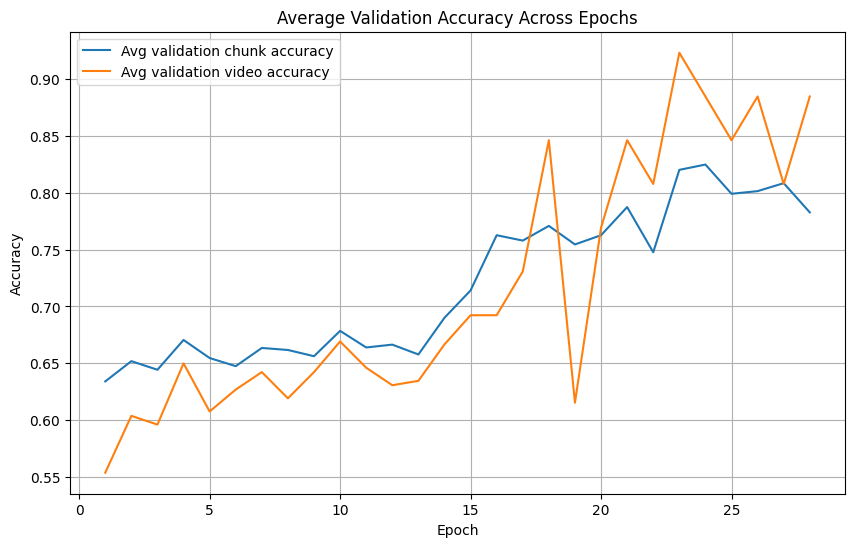

In [ ]:
# Plot acc across epoch both chunk level and video level
# =========================
# [ADDED] PLOT AVERAGE VALIDATION ACCURACY ACROSS EPOCHS
# =========================
max_len = max(len(curve) for curve in all_chunk_val_curves)

chunk_mat = np.full((len(all_chunk_val_curves), max_len), np.nan)
video_mat = np.full((len(all_video_val_curves), max_len), np.nan)

for k, curve in enumerate(all_chunk_val_curves):
    chunk_mat[k, :len(curve)] = curve

for k, curve in enumerate(all_video_val_curves):
    video_mat[k, :len(curve)] = curve

avg_chunk_curve = np.nanmean(chunk_mat, axis=0)
avg_video_curve = np.nanmean(video_mat, axis=0)

epochs_axis = np.arange(1, max_len + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_axis, avg_chunk_curve, label='Avg validation chunk accuracy')
plt.plot(epochs_axis, avg_video_curve, label='Avg validation video accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Average Validation Accuracy Across Epochs')
plt.legend()
plt.grid(True)
plt.show()

### 4. Train ONE final model to get weights

Train: 3226 Counter({np.int8(1): 1261, np.int8(0): 1082, np.int8(2): 883})
Val:   311 Counter({np.int8(1): 119, np.int8(2): 115, np.int8(0): 77})
Train videos: 207
Val videos:   23


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 110, 110, 64)   │       154,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 774400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   198,246,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,402,051 (756.84 MB)

 Trainable params: 198,402,051 (756.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.5678 - loss: 1.2053
Epoch 1: val_loss improved from None to 0.76616, saving model to weights/LSTM.keras

Epoch 1: finished saving model to weights/LSTM.keras
 — val_chunk_acc_manual: 0.5756 — val_video_acc: 0.5217
807/807 ━━━━━━━━━━━━━━━━━━━━ 152s 179ms/step - accuracy: 0.6376 - loss: 0.8518 - val_accuracy: 0.5756 - val_loss: 0.7662
Epoch 2/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7594 - loss: 0.5343
Epoch 2: val_loss improved from 0.76616 to 0.72769, saving model to weights/LSTM.keras

Epoch 2: finished saving model to weights/LSTM.keras
 — val_chunk_acc_manual: 0.5981 — val_video_acc: 0.5652
807/807 ━━━━━━━━━━━━━━━━━━━━ 135s 167ms/step - accuracy: 0.7588 - loss: 0.5319 - val_accuracy: 0.5981 - val_loss: 0.7277
Epoch 3/100
807/807 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8252 - loss: 0.4102
Epoch 3: val_loss improved from 0.72769 to 0.69885, saving model to weights/LSTM.keras

Epoch 3: fin

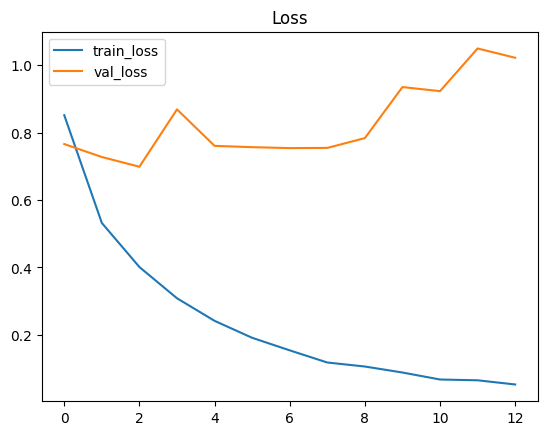

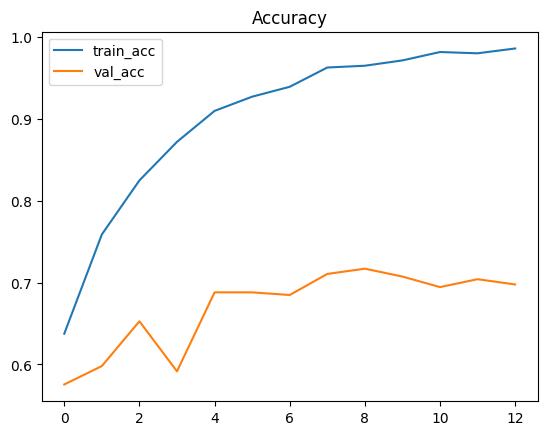

In [ ]:
# =========================
# FINAL TRAINING: one model with 10% validation
# =========================

import os
import gc
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# -------------------------
# 0. clean memory first
# -------------------------
tf.keras.backend.clear_session()
gc.collect()

# optional but helpful for Colab / GPU stability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass

# -------------------------
# 1. load full dataset
# -------------------------
chunk_number = count_chunks(OUT)

X = np.memmap(
    os.path.join(OUT, "samples.mmap"),
    mode='r',
    dtype=np.float32,
    shape=(chunk_number, 16, 112, 112, 3)
)

y = np.memmap(
    os.path.join(OUT, "labels.mmap"),
    mode='r',
    dtype=np.int8,
    shape=(chunk_number,)
)

videoname = np.memmap(
    os.path.join(OUT, 'videos.mmap'),
    mode='r',
    dtype=np.int32,
    shape=(chunk_number,)
)

# -------------------------
# 2. 90/10 split by video
# -------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, val_idx = next(gss.split(np.zeros(chunk_number), y, groups=videoname))

# labels / groups
y_train = np.asarray(y)[train_idx]
y_val = np.asarray(y)[val_idx]
video_train = np.asarray(videoname)[train_idx]
video_val = np.asarray(videoname)[val_idx]

# -------------------------
# 3. save train/val into separate memmaps
#    (safer than X[train_idx] directly)
# -------------------------
X_train = np.memmap(
    os.path.join(OUT, 'samples_train_final.mmap'),
    mode='w+',
    dtype=np.float32,
    shape=(len(train_idx), 16, 112, 112, 3)
)
X_train[:] = X[train_idx][:]

X_val = np.memmap(
    os.path.join(OUT, 'samples_val_final.mmap'),
    mode='w+',
    dtype=np.float32,
    shape=(len(val_idx), 16, 112, 112, 3)
)
X_val[:] = X[val_idx][:]

print("Train:", len(X_train), Counter(y_train))
print("Val:  ", len(X_val), Counter(y_val))
print("Train videos:", len(np.unique(video_train)))
print("Val videos:  ", len(np.unique(video_val)))

# optional: free original full X mapping
del X
gc.collect()

# -------------------------
# 4. build one final model
# -------------------------
# choose the model function you want:
# get3DCNNLSTMModel(...)
# getLSTMModel(...)
# or another getModel(...)
#
# if you want frozen pretrained backbone:
# model = get3DCNNLSTMModel(freeze_backbone=True, lr=1e-5)
# model = getC3DCNNModel(freeze_backbone=True, lr=1e-5)
model = getLSTMModel(freeze_backbone=True, lr=1e-5)


# -------------------------
# 5. callbacks
# -------------------------
es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

# filepath = 'weights/3DCNNLSTM.keras'
# filepath = 'weights/C3DCNN.keras'
filepath = 'weights/LSTM.keras'

ckpt = ModelCheckpoint(
    filepath=filepath,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

video_val_cb = VideoValAccuracyCallback(
    X_val=X_val,
    y_val=y_val,
    video_val=video_val,
    n_classes=3
)

# -------------------------
# 6. train
# -------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=4,
    verbose=1,
    callbacks=[es, ckpt, video_val_cb]
)

# -------------------------
# 7. save final model / weights
# -------------------------
# model.save("final_model_last.h5")
# model.save_weights("final_model_weights.weights.h5")

# -------------------------
# 8. print best epoch info
# -------------------------
best_epoch = np.argmin(history.history['val_loss'])
print(f"\nBest epoch: {best_epoch + 1}")
print(f"Train loss at best epoch: {history.history['loss'][best_epoch]:.4f}")
print(f"Val loss at best epoch:   {history.history['val_loss'][best_epoch]:.4f}")

if 'accuracy' in history.history and 'val_accuracy' in history.history:
    print(f"Train acc at best epoch: {history.history['accuracy'][best_epoch]:.4f}")
    print(f"Val acc at best epoch:   {history.history['val_accuracy'][best_epoch]:.4f}")

# -------------------------
# 9. plot curves
# -------------------------
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

if 'accuracy' in history.history and 'val_accuracy' in history.history:
    plt.figure()
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.legend()
    plt.title("Accuracy")
    plt.show()